# Forecasting Energy Demand
Dataset: Our World in Data World Energy Consumption  
Tools: Using Python, Facebook Prophet, XGBoost, Plotly  


## Project Overview
Energy demand forecasting is a critical challenge across utility companies, governement and private industry. 

Accurate forecasts enable better infrastructure planning, cost optimization and sustainability decisions.

This project aims to accurately forecast energy demand by building a forecsting system using a machine learning approach.

## Table of Contents
1. Environment setup and data loading
2. Exploratory data analysis (EDA)
3. Data cleaning, feature engineering and feature selection
4. Building a baseline forecasting model (Moving averages)
5. Intermediate forecasting model (Prophet)
6. Advanced forecasting (XGBoost)
7. Model comparison and business interpretation

### 1. Environment setup and data loading

In [1]:
!pip install kaggle prophet xgboost shap plotly --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
# data ingestion recommended approach using Kaggle API
# credentials are stored in a .env file excluded from version control via .gitignore
#Anaconda Cloud has a proxy restriction that blocked the Kaggle API during development.
# See next cell for workaround

# from dotenv import load_dotenv
# import os
# load_dotenv()
# os.environ['KAGGLE_USERNAME'] = os.getenv('KAGGLE_USERNAME')
# os.environ['KAGGLE_KEY'] = os.getenv('KAGGLE_KEY')
# !~/.local/bin/kaggle datasets download -d pralabhpoudel/world-energy-consumption --unzip --quiet

In [5]:
#manually upload the csv file as a workaround
#data source: https://www.kaggle.com/datasets/pralabhpoudel/world-energy-consumption


df = pd.read_csv('World Energy Consumption.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (22012, 129)


In [6]:
### 2. Exploratory data analysis (EDA)

In [7]:
# inspecting dataset structure

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nYear range: {df['year'].min()} - {df['year'].max()}")
print(f"Countries covered: {df['country'].nunique()}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Rows: 22,012
Columns: 129

Year range: 1900 - 2022
Countries covered: 306

Column names:
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 

In [8]:
# 306 countries seem off
# further inspection

print(df['country'].unique())

['ASEAN (Ember)' 'Afghanistan' 'Africa' 'Africa (EI)' 'Africa (Ember)'
 'Africa (Shift)' 'Albania' 'Algeria' 'American Samoa' 'Angola'
 'Antarctica' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Asia'
 'Asia & Oceania (EIA)' 'Asia (Ember)' 'Asia Pacific (EI)'
 'Asia and Oceania (Shift)' 'Australia' 'Australia and New Zealand (EIA)'
 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'CIS (EI)' 'Cambodia'
 'Cameroon' 'Canada' 'Cape Verde' 'Cayman Islands'
 'Central & South America (EIA)' 'Central African Republic'
 'Central America (EI)' 'Central and South America (Shift)' 'Chad' 'Chile'
 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Czechoslovakia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'

In [9]:
#evaluate candidate countries for further analysis
# prorities countries that has compelling energy stories
# also check for sufficient data for reliable forecasting

candidates = ['United States', 'China', 'India', 'Germany', 'Denmark', 'Norway', 'United Kingdom', 'Brazil']

for country in candidates:
    subset = df[df['country'] == country]
    years = subset['year'].nunique()
    missing = subset['primary_energy_consumption'].isnull().sum()
    print(f"{country:<20} Years: {years} missing energy values: {missing}")

United States        Years: 123 missing energy values: 65
China                Years: 123 missing energy values: 65
India                Years: 123 missing energy values: 65
Germany              Years: 123 missing energy values: 65
Denmark              Years: 123 missing energy values: 65
Norway               Years: 123 missing energy values: 65
United Kingdom       Years: 123 missing energy values: 65
Brazil               Years: 123 missing energy values: 65


In [10]:
# Check actual year range per country
subset = df[df['country'] == 'Germany']
print(subset['year'].unique())

# Check what the missing values look like
print(subset[['year', 'primary_energy_consumption']].head(30))

[1900 1901 1902 1903 1904 1905 1906 1907 1908 1909 1910 1911 1912 1913
 1914 1915 1916 1917 1918 1919 1920 1921 1922 1923 1924 1925 1926 1927
 1928 1929 1930 1931 1932 1933 1934 1935 1936 1937 1938 1939 1940 1941
 1942 1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955
 1956 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969
 1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983
 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]
      year  primary_energy_consumption
7681  1900                         NaN
7682  1901                         NaN
7683  1902                         NaN
7684  1903                         NaN
7685  1904                         NaN
7686  1905                         NaN
7687  1906                         NaN
7688  1907                         NaN
7689  1908              

In [11]:
# data range is from 1900-2022
# data pre -1930 is largely absent across all countries
# this is not a data quality issue rather it's a historical limitation.


df_filtered = df[df['year'] >= 1965]

# Recheck completeness on filtered dataset
candidates = ['United States', 'China', 'India', 'Germany', 
              'Denmark', 'Norway', 'United Kingdom', 'Brazil']

for country in candidates:
    subset = df_filtered[df_filtered['country'] == country]
    years = subset['year'].nunique()
    missing = subset['primary_energy_consumption'].isnull().sum()
    print(f"{country:<20} Years: {years}  Missing energy values: {missing}")

United States        Years: 58  Missing energy values: 0
China                Years: 58  Missing energy values: 0
India                Years: 58  Missing energy values: 0
Germany              Years: 58  Missing energy values: 0
Denmark              Years: 58  Missing energy values: 0
Norway               Years: 58  Missing energy values: 0
United Kingdom       Years: 58  Missing energy values: 0
Brazil               Years: 58  Missing energy values: 0


In [12]:
# we pick US, China and India as our focus for this project
# US - mature consumption-driven economy
# China - manufacturing powerhouse in transition 
# India - rapidly developing economy with surging demand
# they account for ~40% of global energy consumption


countries = ['United States', 'China', 'India']

df_selected = df_filtered[df_filtered['country'].isin(countries)][
    ['country', 'year', 'primary_energy_consumption']
].reset_index(drop=True)

In [13]:
df_selected.shape

(174, 3)

In [14]:
df_selected.groupby('country')['year'].agg(['min','max','count'])

,min,max,count
country,,,
China,1965,2022,58
India,1965,2022,58
United States,1965,2022,58


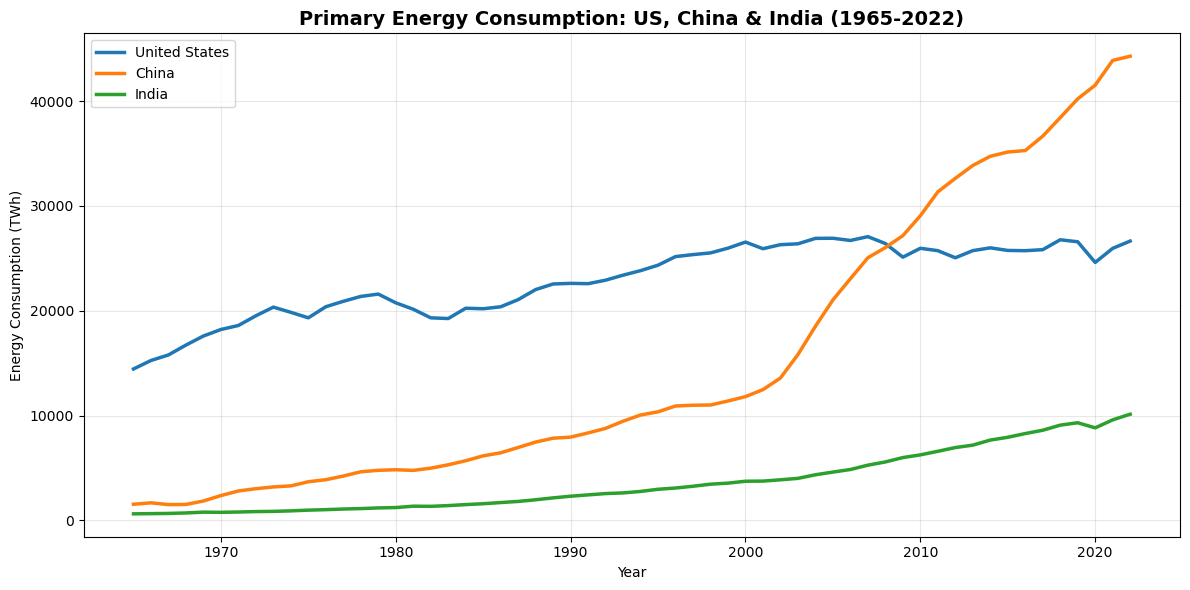

In [16]:
#visualising historical energy consumption

fig, ax = plt.subplots(figsize=(12,6))

for country in countries:
    subset = df_selected[df_selected['country'] == country]
    ax.plot(subset['year'], subset['primary_energy_consumption'],
    label=country, linewidth=2.5)

ax.set_title('Primary Energy Consumption: US, China & India (1965-2022)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Energy Consumption (TWh)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()